# 02 Vector Workflows: Labels in GeoJSON and GeoPackage
**Repo:** local_contexts_geospatial  
**Author:** Lilly Jones, PhD, Daear Consulting, LLC  

## What This Notebook Covers
Vector geospatial data (points, lines, and polygons stored in GeoJSON
or GeoPackage format) is where most Tribal environmental monitoring
data lives: well locations, pasture boundaries, species observation
points, cultural site polygons.

This notebook shows two approaches to embedding TK/BC labels in vector data:

1. **GeoJSON properties** label fields at the feature level
2. **GeoDataFrame attributes** label columns in a pandas/geopandas workflow
3. **GeoPackage metadata** labels in the file-level metadata layer
4. **Spatial label assignment** assigning labels based on which
   Tribal boundary a feature falls within

## Data
- **Real:** Census TIGER AIANNH boundaries (SD Tribal Nations)
- **Synthetic:** Vegetation survey points (created in this notebook)

In [9]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import warnings
import zipfile, io, tempfile, requests

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from shapely.validation import make_valid

from localcontexts.labels import (
    TKLabel, BCLabel, TKMetadata, BCMetadata,
    has_any_label, extract_tk_fields,
)
from localcontexts.propagation import propagate_labels
from localcontexts.validation import validate_usage, validate_label_present
from localcontexts.spatial import (
    assign_labels_to_geodataframe,
    get_label_coverage_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

DATA_DIR   = REPO_ROOT/"data"
REAL_DIR   = DATA_DIR/"real"
SYNTH_DIR  = DATA_DIR/"synthetic"
REAL_DIR.mkdir(parents=True, exist_ok=True)
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete.")

Imports complete.


## Load Tribal Boundaries

In [2]:
AIANNH_CACHE = REAL_DIR/"tl_2023_us_aiannh.geojson"

SD_NAMES = [
    "Pine Ridge", "Rosebud", "Standing Rock", "Cheyenne River",
    "Lower Brule", "Crow Creek", "Lake Traverse", "Flandreau",
]
COMMON_NAMES = {
    "Pine Ridge":     "Oglala Lakota",
    "Rosebud":        "Sicangu",
    "Standing Rock":  "Standing Rock",
    "Cheyenne River": "Cheyenne River",
    "Lower Brule":    "Lower Brule",
    "Crow Creek":     "Crow Creek",
    "Lake Traverse":  "Sisseton Wahpeton Oyate",
    "Flandreau":      "Flandreau Santee",
}

if AIANNH_CACHE.exists():
    all_aiannh = gpd.read_file(AIANNH_CACHE)
    print(f"AIANNH loaded from cache")
else:
    print("Downloading Census TIGER AIANNH...")
    url = "https://www2.census.gov/geo/tiger/TIGER2023/AIANNH/tl_2023_us_aiannh.zip"
    r   = requests.get(url, timeout=300)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        with tempfile.TemporaryDirectory() as tmp:
            z.extractall(tmp)
            shp = next(Path(tmp).glob("*.shp"))
            all_aiannh = gpd.read_file(shp).to_crs("EPSG:4326")
    all_aiannh.to_file(AIANNH_CACHE, driver="GeoJSON")
    print("Downloaded and cached.")

sd_tribes = all_aiannh[all_aiannh["NAME"].isin(SD_NAMES)].copy()
sd_tribes = sd_tribes.dissolve(by="NAME", as_index=False)
sd_tribes["geometry"]    = sd_tribes.geometry.apply(make_valid)
sd_tribes["common_name"] = sd_tribes["NAME"].map(COMMON_NAMES)

print(f"SD Tribal Nations loaded: {len(sd_tribes)}")
print(sd_tribes[["NAME", "common_name"]].to_string(index=False))

Downloaded and cached.
SD Tribal Nations loaded: 8
          NAME             common_name
Cheyenne River          Cheyenne River
    Crow Creek              Crow Creek
     Flandreau        Flandreau Santee
 Lake Traverse Sisseton Wahpeton Oyate
   Lower Brule             Lower Brule
    Pine Ridge           Oglala Lakota
       Rosebud                 Sicangu
 Standing Rock           Standing Rock


## Create Synthetic Vegetation Survey Points

In [3]:
# Generate synthetic vegetation survey points scattered across SD Tribal lands
# These represent hypothetical field observations this is NOT real data

np.random.seed(42)

survey_points = []
for _, tribe in sd_tribes.iterrows():
    bounds = tribe.geometry.bounds
    n_pts  = np.random.randint(5, 15)
    for _ in range(n_pts):
        # Random point inside the bounding box
        # (some will fall outside the polygon)
        lon = np.random.uniform(bounds[0], bounds[2])
        lat = np.random.uniform(bounds[1], bounds[3])
        survey_points.append({
            "site_id":      f"{tribe['NAME'][:3].upper()}_{len(survey_points):04d}",
            "tribe_name":   tribe["NAME"],
            "common_name":  tribe["common_name"],
            "ndvi":         round(np.random.uniform(0.15, 0.65), 3),
            "cover_pct":    round(np.random.uniform(20, 90), 1),
            "survey_date":  f"2023-{np.random.randint(5,10):02d}-{np.random.randint(1,28):02d}",
            "geometry":     Point(lon, lat),
        })

survey_gdf = gpd.GeoDataFrame(survey_points, crs="EPSG:4326")

print(f"Synthetic survey points created: {len(survey_gdf)}")
print("\nNOTE: This data is synthetic: created for demonstration only.")
print(survey_gdf.head(4)[["site_id","common_name","ndvi","cover_pct"]].to_string(index=False))

Synthetic survey points created: 81

NOTE: This data is synthetic: created for demonstration only.
 site_id    common_name  ndvi  cover_pct
CHE_0000 Cheyenne River 0.540       61.8
CHE_0001 Cheyenne River 0.317       30.0
CHE_0002 Cheyenne River 0.619       20.1
CHE_0003 Cheyenne River 0.154       21.6


## Approach A: Feature-Level GeoJSON Labels
Add TK label fields directly to each GeoJSON feature's properties.
This is the most portable approach, any GIS software that can read
GeoJSON files will see the label fields.

In [4]:
# Define labels per Tribal Nation
# In practice these would come from the actual community governance office

TRIBAL_LABELS = {
    "Oglala Lakota": TKMetadata(
        label     = TKLabel.NON_COMMERCIAL,
        community = "Oglala Lakota Nation",
        authority = "Tribal Data Governance Office",
        usage     = "Non-commercial environmental research only",
        contact   = "data@oglalalakota.org",
    ),
    "Rosebud Sioux": TKMetadata(
        label     = TKLabel.NON_COMMERCIAL,
        community = "Rosebud Sioux Tribe",
        authority = "RST Natural Resources Department",
        usage     = "Non-commercial research; share results with NRD",
        contact   = "nrd@rosebudsiouxtribe.org",
    ),
    # Default for other Nations: TK Notice signals Indigenous interest
    # without a specific label yet assigned
    "_default": TKMetadata(
        label     = TKLabel.NOTICE,
        community = "South Dakota Tribal Nation",
        authority = "Pending community assignment",
        usage     = (
            "Indigenous interests exist in this data. "
            "Contact the relevant Tribal Nation before use."
        ),
    ),
}

# Add TK label fields to each survey point
def get_label(common_name):
    return TRIBAL_LABELS.get(common_name, TRIBAL_LABELS["_default"])

labeled_points = survey_gdf.copy()
for field in ["tk:label", "tk:community", "tk:authority", "tk:usage", "tk:contact"]:
    labeled_points[field] = None

for idx, row in labeled_points.iterrows():
    tk = get_label(row["common_name"])
    tk_dict = tk.to_dict()
    for field, value in tk_dict.items():
        if field in labeled_points.columns:
            labeled_points.at[idx, field] = value

print(f"Labeled {len(labeled_points)} survey points")
print("\nSample labeled features:")
print(
    labeled_points[
        ["site_id", "common_name", "tk:label", "tk:community"]
    ].head(6).to_string(index=False)
)

Labeled 81 survey points

Sample labeled features:
 site_id    common_name  tk:label               tk:community
CHE_0000 Cheyenne River TK Notice South Dakota Tribal Nation
CHE_0001 Cheyenne River TK Notice South Dakota Tribal Nation
CHE_0002 Cheyenne River TK Notice South Dakota Tribal Nation
CHE_0003 Cheyenne River TK Notice South Dakota Tribal Nation
CHE_0004 Cheyenne River TK Notice South Dakota Tribal Nation
CHE_0005 Cheyenne River TK Notice South Dakota Tribal Nation


In [5]:
# Save as GeoJSON so that labels travel with the file
output_path = SYNTH_DIR/"pine_ridge_synthetic_vegetation.geojson"
labeled_points.to_file(output_path, driver="GeoJSON")
print(f"Saved: {output_path}")

# Verify labels survive the round trip
reloaded = gpd.read_file(output_path)
print(f"\nReloaded: {len(reloaded)} features")
print(f"TK label column present: {'tk:label' in reloaded.columns}")
print(f"Unique TK labels: {reloaded['tk:label'].unique()}")

Saved: C:\Users\gekek\Documents\local contexts\TEK_labels\data\synthetic\pine_ridge_synthetic_vegetation.geojson

Reloaded: 81 features
TK label column present: True
Unique TK labels: <StringArray>
['TK Notice', 'TK Non-Commercial']
Length: 2, dtype: str


## Approach B: Spatial Label Assignment
When you have a large dataset without labels, you can assign labels
automatically based on which Tribal boundary each feature intersects.
The `assign_labels_to_geodataframe()` function handles this.

In [6]:
# Build a label zones GeoDataFrame from the Tribal boundaries
label_zones = sd_tribes[["common_name", "geometry"]].copy()
label_zones["tk_label"] = label_zones["common_name"].apply(
    lambda n: TRIBAL_LABELS.get(n, TRIBAL_LABELS["_default"]).label.value
)

# Assign labels spatially
spatially_labeled = assign_labels_to_geodataframe(
    gdf        = survey_gdf,
    label_zones = label_zones,
    label_col   = "tk_label",
    community_col = "common_name",
    output_label_col     = "tk_label_spatial",
    output_community_col = "tk_community_spatial",
)

print("\nSpatial label assignment result:")
print(
    spatially_labeled[
        ["site_id", "common_name", "tk_label_spatial", "tk_community_spatial"]
    ].head(8).to_string(index=False)
)

Spatial label assignment complete:
  47 features labeled
  34 features have no overlapping label zone

Spatial label assignment result:
 site_id    common_name tk_label_spatial tk_community_spatial
CHE_0000 Cheyenne River              NaN                 None
CHE_0001 Cheyenne River        TK Notice                 None
CHE_0002 Cheyenne River        TK Notice                 None
CHE_0003 Cheyenne River        TK Notice                 None
CHE_0004 Cheyenne River              NaN                 None
CHE_0005 Cheyenne River        TK Notice                 None
CHE_0006 Cheyenne River        TK Notice                 None
CHE_0007 Cheyenne River        TK Notice                 None


In [7]:
# Coverage report
report = get_label_coverage_report(spatially_labeled, label_col="tk_label_spatial")
print("\nLabel coverage report:")
print(json.dumps(
    {k: v for k, v in report.items() if k != "label_distribution"},
    indent=2
))


Label coverage report:
{
  "total_features": 81,
  "labeled_features": 47,
  "unlabeled_features": 34,
  "label_coverage_pct": 58.0
}


## Map Labeled Vector Data

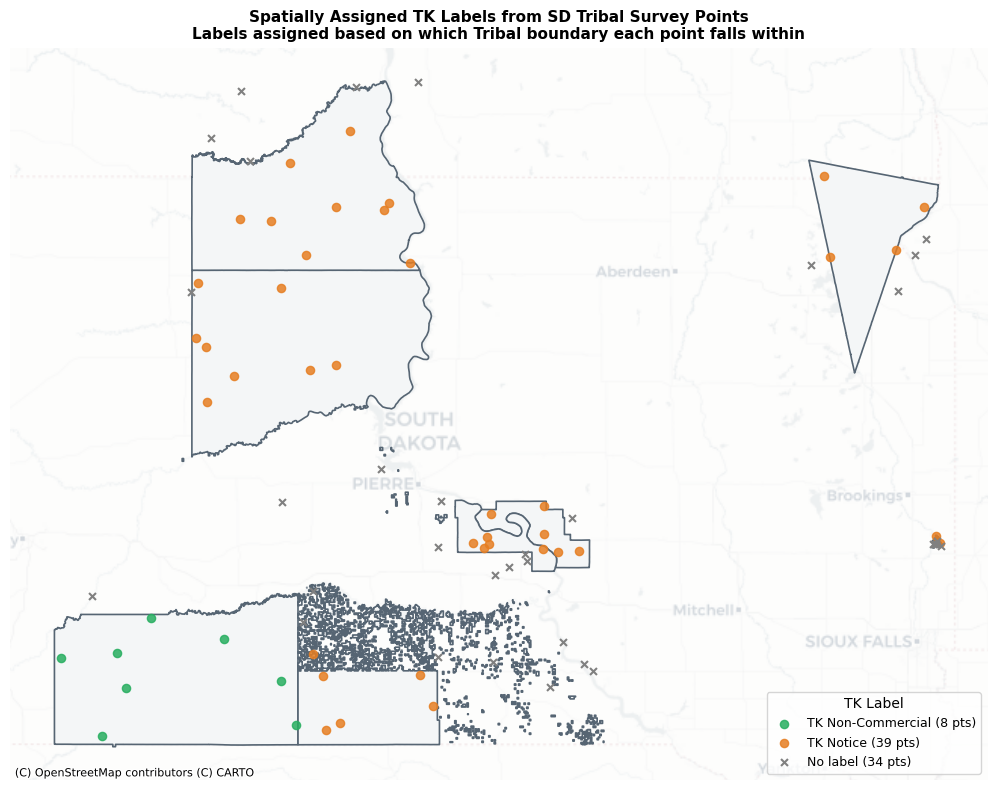

In [8]:
LABEL_COLORS = {
    TKLabel.NON_COMMERCIAL.value: "#27AE60",
    TKLabel.NOTICE.value:         "#E67E22",
    TKLabel.CULTURALLY_SENSITIVE.value: "#C0392B",
}

fig, ax = plt.subplots(figsize=(12, 8))

# Tribal boundaries
sd_tribes.to_crs(3857).plot(
    ax=ax, facecolor="#F4F6F7", edgecolor="#566573",
    linewidth=1.2, zorder=1,
)

# Survey points colored by TK label
for label_val, color in LABEL_COLORS.items():
    subset = spatially_labeled[spatially_labeled["tk_label_spatial"] == label_val]
    if not subset.empty:
        subset.to_crs(3857).plot(
            ax=ax, color=color, markersize=35, marker="o",
            alpha=0.85, zorder=3,
            label=f"{label_val} ({len(subset)} pts)",
        )

# Points with no label
unlabeled = spatially_labeled[spatially_labeled["tk_label_spatial"].isna()]
if not unlabeled.empty:
    unlabeled.to_crs(3857).plot(
        ax=ax, color="gray", markersize=25, marker="x",
        zorder=3, label=f"No label ({len(unlabeled)} pts)",
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower right", title="TK Label")
ax.set_title(
    "Spatially Assigned TK Labels from SD Tribal Survey Points\n"
    "Labels assigned based on which Tribal boundary each point falls within",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Summary
| Approach | Best for | Limitation |
|---|---|---|
| Feature-level GeoJSON fields | Feature-by-feature governance | Adds many columns |
| Spatial assignment | Bulk labeling of large datasets | Requires boundary layer |
| GeoPackage metadata layer | File-level governance | Not all software reads metadata |

## Next Notebook
**03 Raster Workflows:** Embedding TK/BC labels in GeoTIFF metadata
tags using rasterio approach for satellite-derived raster products.